# 3.0 Interpretação e Entrega de Valor - Milestone 4

**Projeto:** Desenvolvimento de um Modelo Preditivo para Apoio à Decisão de Crédito com Machine Learning  
**Grupo 5:** Iara Gomes · Rita Vinagreiro · Ana Silva  
**Docente:** Dora Melo | Coimbra Business School | ISCAC

## O que este notebook responde

1. O que é que o modelo resolveu?
2. Podemos confiar nos resultados?  
3. E agora, o que fazemos com esta informação?

# Carregamento dos Dados
(Ana Silva)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# Avaliação
from sklearn.metrics import (
    f1_score, roc_auc_score, recall_score,
    classification_report, ConfusionMatrixDisplay,
    roc_curve, confusion_matrix, make_scorer
)

# Validação
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_validate, cross_val_score, learning_curve, 
    GridSearchCV
)

# Pipelines
from imblearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/ritavinagreiro2/germanprocessed/german_processed.csv
/kaggle/input/datasets/mpwolke/cusersmarildownloadsgermancsv/german.csv


In [2]:
df = pd.read_csv("/kaggle/input/datasets/ritavinagreiro2/germanprocessed/german_processed.csv")

In [3]:
df.head(15)

,Creditability,Account_Balance,Duration_of_Credit_monthly,Payment_Status_of_Previous_Credit,Purpose,Credit_Amount,Value_Savings_Stocks,Length_of_current_employment,Instalment_per_cent,Sex_Marital_Status,Guarantors,Duration_in_Current_address,Most_valuable_available_asset,Age_years,Concurrent_Credits,Type_of_apartment,No_of_Credits_at_this_Bank,Occupation,Credit_per_Month,Credit_Age_Ratio
0,1,1,-0.240857,4,2,-0.787657,1,2,4,2,1,4,2,-1.281573,3,1,1,3,-0.713147,-0.543155
1,1,1,-0.987573,4,0,-0.167384,1,3,2,3,1,2,1,0.040363,3,1,2,3,0.934161,-0.238406
2,1,2,-0.738668,2,9,-0.861381,2,4,2,2,1,4,1,-1.105315,3,1,1,2,-0.636195,-0.689919
3,1,1,-0.738668,4,0,-0.407341,1,3,3,3,1,2,1,0.304750,3,1,2,2,0.059628,-0.494282
4,1,1,-0.738668,4,0,-0.389974,1,3,4,3,1,4,2,0.216621,1,2,2,2,0.086245,-0.464448
5,1,1,-0.904604,4,0,-0.365163,1,2,1,3,1,3,1,1.097912,3,1,2,2,0.367725,-0.578948
6,1,1,-1.070541,4,0,0.044926,1,4,1,3,1,4,1,0.304750,3,2,2,2,1.675613,-0.135592
7,1,1,-1.236478,4,0,-0.677071,1,2,2,3,1,4,1,0.392879,3,2,1,2,0.385541,-0.717768
8,1,4,-0.240857,4,3,-0.770289,1,1,4,2,1,4,3,2.596106,3,2,2,1,-0.695403,-0.905596
9,1,2,0.256953,2,3,0.172525,3,1,1,2,1,4,4,-1.105315,3,1,1,1,-0.072366,0.700489


In [4]:
# Verificação básica do dataset
print('Colunas do dataset:')
print(df.columns.tolist())

print('\nValores em falta por coluna:')
display(df.isna().sum().to_frame('N.º de valores em falta'))

print('\nDistribuição da variável alvo Creditability:')
distribuicao = pd.DataFrame({
    'N.º de clientes': df['Creditability'].value_counts().sort_index(),
    'Percentagem (%)': (df['Creditability'].value_counts(normalize=True).sort_index() * 100).round(2)
})
display(distribuicao)

Colunas do dataset:
['Creditability', 'Account_Balance', 'Duration_of_Credit_monthly', 'Payment_Status_of_Previous_Credit', 'Purpose', 'Credit_Amount', 'Value_Savings_Stocks', 'Length_of_current_employment', 'Instalment_per_cent', 'Sex_Marital_Status', 'Guarantors', 'Duration_in_Current_address', 'Most_valuable_available_asset', 'Age_years', 'Concurrent_Credits', 'Type_of_apartment', 'No_of_Credits_at_this_Bank', 'Occupation', 'Credit_per_Month', 'Credit_Age_Ratio']

Valores em falta por coluna:


,N.º de valores em falta
Creditability,0
Account_Balance,0
Duration_of_Credit_monthly,0
Payment_Status_of_Previous_Credit,0
Purpose,0
Credit_Amount,0
Value_Savings_Stocks,0
Length_of_current_employment,0
Instalment_per_cent,0
Sex_Marital_Status,0



Distribuição da variável alvo Creditability:


,N.º de clientes,Percentagem (%)
Creditability,,
0,300,30.0
1,700,70.0


# Divisão Treino / Teste
(Ana Silva)

In [5]:
# DIVISÃO TREINO / TESTE
# Definir features e target
X = df.drop(columns=['Creditability'])
y = df['Creditability']

# Divisão 80/20 
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# Verificação
print(f'Treino: {X_train.shape[0]} observações ({X_train.shape[0]/len(df)*100:.0f}%)')
print(f'Teste: {X_test.shape[0]} observações ({X_test.shape[0]/len(df)*100:.0f}%)')

print('\nDistribuição no Treino:')
print(y_train.value_counts(normalize=True).round(3) * 100)

print('\nDistribuição no Teste:')
print(y_test.value_counts(normalize=True).round(3) * 100)

Treino: 800 observações (80%)
Teste: 200 observações (20%)

Distribuição no Treino:
Creditability
1    70.0
0    30.0
Name: proportion, dtype: float64

Distribuição no Teste:
Creditability
1    70.0
0    30.0
Name: proportion, dtype: float64


# Modelo Baseline

(Iara Gomes)

### Classificação - Regressão Logística

In [6]:
# Treino do Baseline - Cria e treina o modelo de Regressão Logística
baseline = LogisticRegression(max_iter=1000, random_state=42)
baseline.fit(X_train, y_train)

# Avaliação
y_pred_baseline = baseline.predict(X_test) # devolve as classes previstas
y_prob_baseline = baseline.predict_proba(X_test)[:, 1]  # devolve as probabilidades associadas a cada classe

# Métricas principais
f1_baseline  = f1_score(y_test, y_pred_baseline) # mede o equilibrio entre precisison e recall
auc_baseline = roc_auc_score(y_test, y_prob_baseline)   
recall_mau_baseline = recall_score(y_test, y_pred_baseline, pos_label=0)

# Cross-Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# F1 no CV
cv_f1_baseline = cross_val_score(
    baseline,
    X_train,
    y_train,
    cv=cv,
    scoring='f1'
)

recall_mau_scorer = make_scorer(recall_score, pos_label=0)

cv_recall_baseline = cross_val_score(
    baseline,
    X_train,
    y_train,
    cv=cv,
    scoring=recall_mau_scorer
)

# Output
print(' BASELINE: Regressão Logística')
print(f'F1-Score  (Teste): {f1_baseline:.4f}')
print(f'Recall Incumprimento (Teste): {recall_mau_baseline:.4f}')  
print(f'AUC-ROC   (Teste): {auc_baseline:.4f}')
print(f'F1-Score  (CV 5-Fold): {cv_f1_baseline.mean():.4f} ± {cv_f1_baseline.std():.4f}')
print(f'Recall Incumprimento (CV 5-Fold): {cv_recall_baseline.mean():.4f} ± {cv_recall_baseline.std():.4f}')
print()


# Relatório detalhado por classe em DataFrame
report = classification_report(
    y_test,
    y_pred_baseline,
    target_names=['Incumprimento (0)', 'Cumprimento (1)'],
    output_dict=True  # <-- ESTA LINHA É A CHAVE
)

df_report = pd.DataFrame(report).transpose().round(2)

# Corrigir linha accuracy
df_report.loc['accuracy', ['precision', 'recall', 'support']] = ''

# Corrigir support para inteiros
df_report['support'] = df_report['support'].apply(
    lambda x: int(x) if x != '' else ''
)

df_report.style\
    .set_properties(**{'text-align': 'center'})\
    .set_table_styles([{
        'selector': 'th',
        'props': [('background-color', '#4C72B0'), 
                  ('color', 'white'),
                  ('text-align', 'center')]
    }])\
    .format(precision=2, na_rep='')\
    .set_caption('Relatório de Classificação — Baseline Regressão Logística')

 BASELINE: Regressão Logística
F1-Score  (Teste): 0.8464
Recall Incumprimento (Teste): 0.5167
AUC-ROC   (Teste): 0.8145
F1-Score  (CV 5-Fold): 0.8356 ± 0.0322
Recall Incumprimento (CV 5-Fold): 0.4458 ± 0.0680



,precision,recall,f1-score,support
Incumprimento (0),0.66,0.52,0.58,60
Cumprimento (1),0.81,0.89,0.85,140
accuracy,,,0.78,
macro avg,0.74,0.70,0.71,200
weighted avg,0.77,0.78,0.77,200


# Modelo Final - XGBoost + SMOTE

(Iara Gomes)

In [7]:
# Modelo final escolhido na Milestone 3.
pipeline_xgb = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        random_state=42,
    )),
])

pipeline_xgb.fit(X_train, y_train)
print('Pipeline XGBoost + SMOTE reconstruído e treinado para simulação.')

# -------------------------------------------------------------------
# VALORES OFICIAIS DA MILESTONE 3
# -------------------------------------------------------------------

MODELO_FINAL     = 'XGBoost + SMOTE'
THRESHOLD_FINAL  = 0.56

# Baseline — valores oficiais da Milestone 3
F1_BASELINE                   = 0.8464
RECALL_INCUMPRIMENTO_BASELINE = 0.5167
AUC_BASELINE                  = 0.8145

# Modelo final — valores oficiais da Milestone 3
F1_FINAL                   = 0.8213
RECALL_INCUMPRIMENTO_FINAL = 0.7500
AUC_FINAL                  = 0.8090


# Matrizes oficiais da Milestone 3:
# linhas = classe real [Incumprimento (0), Cumprimento (1)]
# colunas = classe prevista [Incumprimento (0), Cumprimento (1)]
cm_baseline = np.array([[31, 29], [16, 124]])
cm_final    = np.array([[45, 15], [32, 108]])

print('\nResultados carregados:')
print(f'Baseline   — F1: {F1_BASELINE:.4f} | Recall: {RECALL_INCUMPRIMENTO_BASELINE:.4f} | AUC: {AUC_BASELINE:.4f}')
print(f'Modelo Final — F1: {F1_FINAL:.4f} | Recall: {RECALL_INCUMPRIMENTO_FINAL:.4f} | AUC: {AUC_FINAL:.4f}')
print(f'Threshold oficial: {THRESHOLD_FINAL:.2f}')

Pipeline XGBoost + SMOTE reconstruído e treinado para simulação.

Resultados carregados:
Baseline   — F1: 0.8464 | Recall: 0.5167 | AUC: 0.8145
Modelo Final — F1: 0.8213 | Recall: 0.7500 | AUC: 0.8090
Threshold oficial: 0.56


In [8]:
# Tabela-resumo comparativa com os valores oficiais da Milestone 3
resultados = pd.DataFrame({
    'Modelo': ['Baseline — Regressão Logística', 'Modelo Final — XGBoost + SMOTE'],
    'F1-Score': [F1_BASELINE, F1_FINAL],
    'Recall Incumprimento': [RECALL_INCUMPRIMENTO_BASELINE, RECALL_INCUMPRIMENTO_FINAL],
    'AUC-ROC': [AUC_BASELINE, AUC_FINAL],
})

display(resultados)

print('Melhoria no Recall do Incumprimento:')
print(f'{RECALL_INCUMPRIMENTO_BASELINE:.4f} → {RECALL_INCUMPRIMENTO_FINAL:.4f} '
      f'(+{RECALL_INCUMPRIMENTO_FINAL - RECALL_INCUMPRIMENTO_BASELINE:.4f})')

,Modelo,F1-Score,Recall Incumprimento,AUC-ROC
0,Baseline — Regressão Logística,0.8464,0.5167,0.8145
1,Modelo Final — XGBoost + SMOTE,0.8213,0.7500,0.8090


Melhoria no Recall do Incumprimento:
0.5167 → 0.7500 (+0.2333)


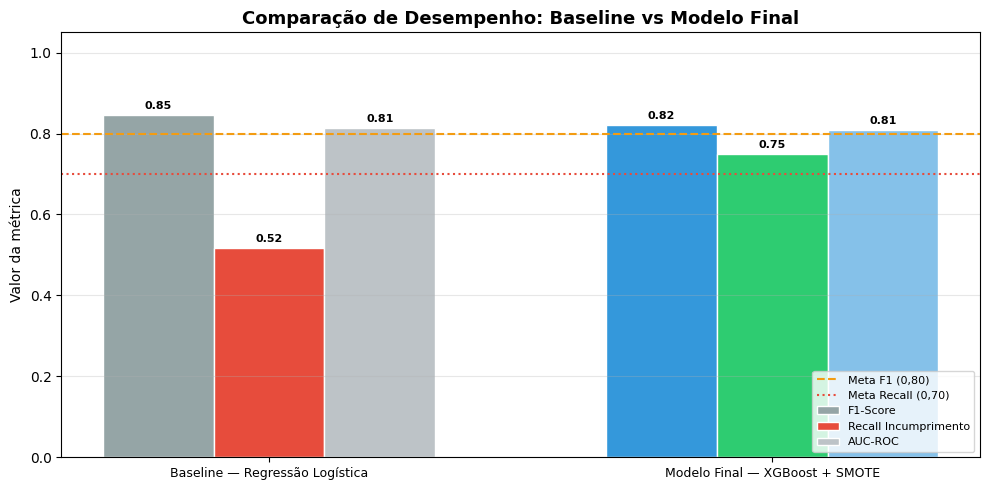

In [9]:
# -------------------------------------------------------------------
# PALETA DE CORES
# -------------------------------------------------------------------
COR_RISCO = '#E74C3C'
COR_OK = '#2ECC71'
COR_AZUL = '#3498DB'
COR_CINZA = '#95A5A6'
COR_OBJETIVO = '#F39C12'

# -------------------------------------------------------------------
# RESULTADOS OFICIAIS
# -------------------------------------------------------------------
resultados = pd.DataFrame({
    'Modelo': [
        'Baseline — Regressão Logística',
        'Modelo Final — XGBoost + SMOTE'
    ],
    'F1-Score': [
        0.8464,
        0.8213
    ],
    'Recall Incumprimento': [
        0.5167,
        0.7500
    ],
    'AUC-ROC': [
        0.8145,
        0.8090
    ]
})

# -------------------------------------------------------------------
# COMPARAÇÃO VISUAL: BASELINE VS MODELO FINAL
# -------------------------------------------------------------------
modelos = resultados['Modelo']
f1_vals = resultados['F1-Score']
recall_vals = resultados['Recall Incumprimento']
auc_vals = resultados['AUC-ROC']

x = np.arange(len(modelos))
w = 0.22

fig, ax = plt.subplots(figsize=(10, 5))

b1 = ax.bar(
    x - w,
    f1_vals,
    w,
    label='F1-Score',
    color=[COR_CINZA, COR_AZUL],
    edgecolor='white'
)

b2 = ax.bar(
    x,
    recall_vals,
    w,
    label='Recall Incumprimento',
    color=[COR_RISCO, COR_OK],
    edgecolor='white'
)

b3 = ax.bar(
    x + w,
    auc_vals,
    w,
    label='AUC-ROC',
    color=['#BDC3C7', '#85C1E9'],
    edgecolor='white'
)

ax.axhline(
    0.80,
    linestyle='--',
    color=COR_OBJETIVO,
    lw=1.5,
    label='Meta F1 (0,80)'
)

ax.axhline(
    0.70,
    linestyle=':',
    color=COR_RISCO,
    lw=1.5,
    label='Meta Recall (0,70)'
)

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h + 0.01,
            f'{h:.2f}',
            ha='center',
            va='bottom',
            fontsize=8,
            fontweight='bold'
        )

ax.set_xticks(x)
ax.set_xticklabels(modelos, fontsize=9)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Valor da métrica')
ax.set_title(
    'Comparação de Desempenho: Baseline vs Modelo Final',
    fontsize=13,
    fontweight='bold'
)

ax.legend(loc='lower right', fontsize=8)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Interpretação dos resultados

O modelo final foi escolhido porque melhora a identificação dos clientes em incumprimento. Mesmo que o F1-Score possa ficar ligeiramente abaixo ou acima do baseline, o ponto principal é que o modelo final aumenta o Recall da classe de risco.

Em linguagem simples: o modelo final é mais útil para uma instituição financeira porque sinaliza mais clientes que podem vir a não pagar.

# Matriz de confusão - onde o modelo acerta e onde falha

(Rita Vinagreiro)

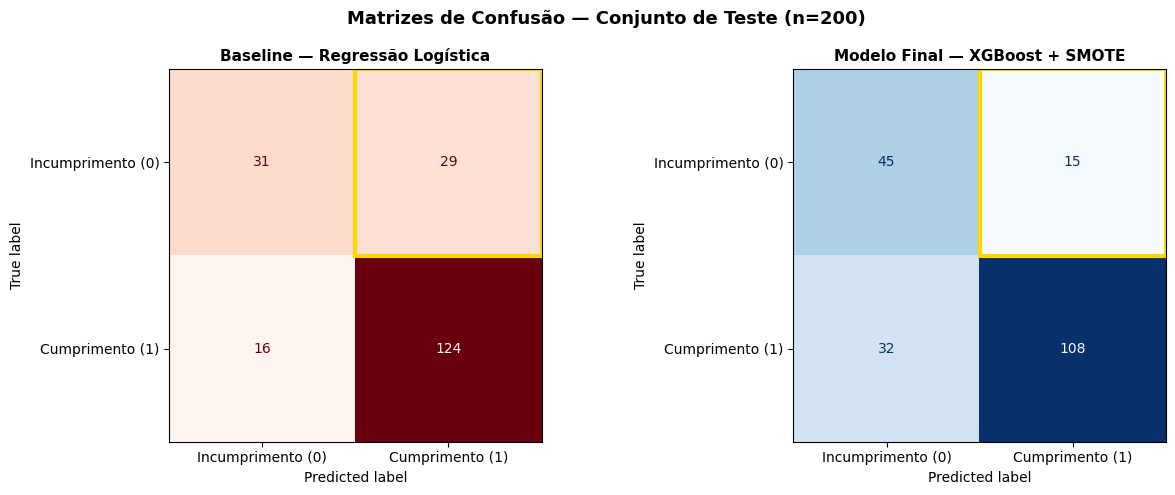

Quadrado dourado = Falsos Negativos: clientes de risco classificados como cumpridores.


In [10]:
# Matrizes de confusão oficiais da Milestone 3
# Baseline: [[31, 29], [16, 124]]
# Modelo final: [[45, 15], [32, 108]]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, cm, titulo, cor in zip(
    axes,
    [cm_baseline, cm_final],
    ['Baseline — Regressão Logística', 'Modelo Final — XGBoost + SMOTE'],
    ['Reds', 'Blues'],
):
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Incumprimento (0)', 'Cumprimento (1)'],
    )
    disp.plot(ax=ax, colorbar=False, cmap=cor)
    ax.set_title(titulo, fontsize=11, fontweight='bold')

    # Destaque do erro mais crítico: Falso Negativo para risco de crédito.
    # True label = Incumprimento (0), Predicted label = Cumprimento (1).
    ax.add_patch(plt.Rectangle((0.5, -0.5), 1, 1, fill=False, edgecolor='gold', lw=3))

plt.suptitle('Matrizes de Confusão — Conjunto de Teste (n=200)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Quadrado dourado = Falsos Negativos: clientes de risco classificados como cumpridores.')

In [11]:
# Interpretação quantitativa das matrizes de confusão
# Estrutura da matriz: [[TN, FP], [FN, TP]] quando as labels são [0,1].
# Aqui, para o problema de crédito, a leitura é:
# [0,0] = incumprimento identificado corretamente
# [0,1] = incumprimento não identificado, o erro mais crítico
# [1,0] = cumpridor sinalizado como risco
# [1,1] = cumpridor identificado corretamente

resumo_erros = pd.DataFrame({
    'Indicador': [
        'Clientes em incumprimento corretamente identificados',
        'Clientes em incumprimento não identificados (Falsos Negativos)',
        'Clientes cumpridores classificados como risco (Falsos Positivos)',
        'Clientes cumpridores corretamente identificados',
    ],
    'Baseline': [cm_baseline[0, 0], cm_baseline[0, 1], cm_baseline[1, 0], cm_baseline[1, 1]],
    'Modelo Final': [cm_final[0, 0], cm_final[0, 1], cm_final[1, 0], cm_final[1, 1]],
    'Interpretação': [
        'Casos de risco sinalizados corretamente',
        'Erro mais crítico: clientes de risco que escapam ao modelo',
        'Clientes que devem ir para análise adicional',
        'Clientes de baixo risco identificados corretamente',
    ],
})

display(resumo_erros)

reducao_fn = (cm_baseline[0, 1] - cm_final[0, 1]) / cm_baseline[0, 1] * 100
print(f'Redução dos falsos negativos face ao baseline: {reducao_fn:.1f}%')

,Indicador,Baseline,Modelo Final,Interpretação
0,Clientes em incumprimento corretamente identif...,31,45,Casos de risco sinalizados corretamente
1,Clientes em incumprimento não identificados (F...,29,15,Erro mais crítico: clientes de risco que escap...
2,Clientes cumpridores classificados como risco ...,16,32,Clientes que devem ir para análise adicional
3,Clientes cumpridores corretamente identificados,124,108,Clientes de baixo risco identificados corretam...


Redução dos falsos negativos face ao baseline: 48.3%


## Interpretação da matriz de confusão

O falso negativo é o erro mais perigoso no contexto de crédito: representa um cliente que efetivamente entra em incumprimento mas que o modelo classificou como bom pagador. O modelo final reduz estes casos de 29 para 15, ou seja, uma redução de 48,3%.

O aumento de falsos positivos (de 16 para 32) é o custo desta melhoria: mais clientes cumpridores são sinalizados para análise adicional. Este trade-off é aceitável, pois o custo de analisar um cliente bom pagador é muito inferior ao custo de conceder crédito a um cliente em incumprimento.

# Segmentação por categoria de risco

(Rita Vinagreiro)

In [12]:
# Segmentação oficial apresentada na Milestone 3
segmentacao_risco = pd.DataFrame({
    'Categoria_Risco': ['Alto Risco', 'Baixo Risco'],
    'Total': [67, 133],
    'Incumpriram': [40, 20],
    'Cumpriram': [27, 113],
    'Taxa de Incumprimento (%)': [59.70, 15.04],
})

display(segmentacao_risco)

,Categoria_Risco,Total,Incumpriram,Cumpriram,Taxa de Incumprimento (%)
0,Alto Risco,67,40,27,59.70
1,Baixo Risco,133,20,113,15.04


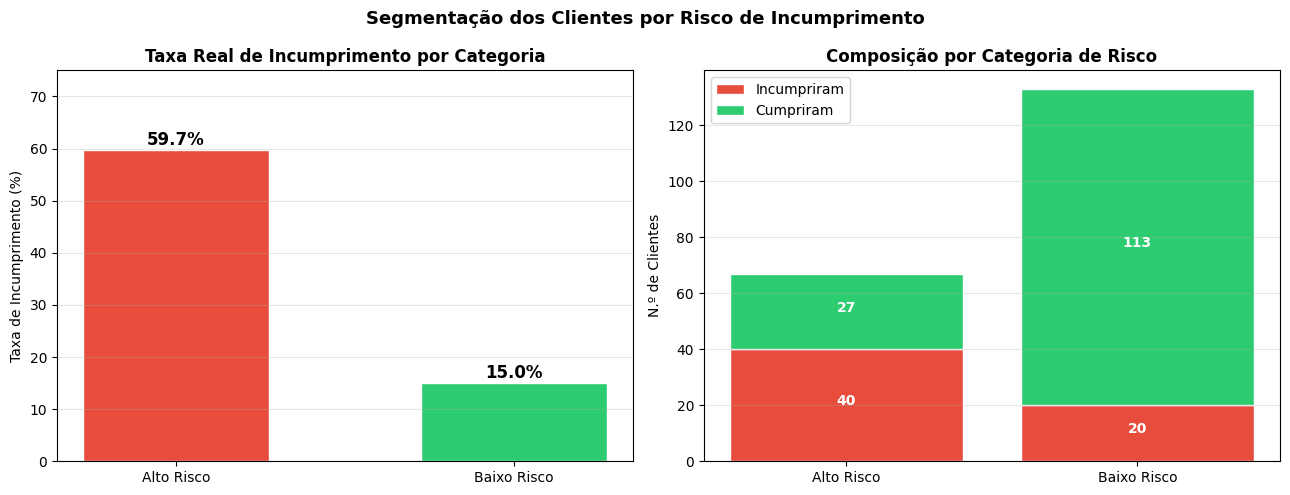

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cores_categoria = [COR_RISCO if cat == 'Alto Risco' else COR_OK for cat in segmentacao_risco['Categoria_Risco']]

# Gráfico 1: taxa de incumprimento por categoria
bars = axes[0].bar(
    segmentacao_risco['Categoria_Risco'],
    segmentacao_risco['Taxa de Incumprimento (%)'],
    color=cores_categoria,
    edgecolor='white',
    width=0.55,
)

for bar, val in zip(bars, segmentacao_risco['Taxa de Incumprimento (%)']):
    axes[0].text(bar.get_x() + bar.get_width() / 2, val + 1,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)

axes[0].set_title('Taxa Real de Incumprimento por Categoria', fontweight='bold')
axes[0].set_ylabel('Taxa de Incumprimento (%)')
axes[0].set_ylim(0, max(75, segmentacao_risco['Taxa de Incumprimento (%)'].max() + 10))
axes[0].grid(axis='y', alpha=0.3)

# Gráfico 2: composição de cada categoria
incumpriram = segmentacao_risco['Incumpriram'].values
cumpriram = segmentacao_risco['Cumpriram'].values
cats = segmentacao_risco['Categoria_Risco'].values

axes[1].bar(cats, incumpriram, label='Incumpriram', color=COR_RISCO, edgecolor='white')
axes[1].bar(cats, cumpriram, bottom=incumpriram, label='Cumpriram', color=COR_OK, edgecolor='white')

for i, (inc, cum) in enumerate(zip(incumpriram, cumpriram)):
    if inc > 0:
        axes[1].text(i, inc / 2, f'{inc}', ha='center', fontweight='bold', color='white')
    if cum > 0:
        axes[1].text(i, inc + cum / 2, f'{cum}', ha='center', fontweight='bold', color='white')

axes[1].set_title('Composição por Categoria de Risco', fontweight='bold')
axes[1].set_ylabel('N.º de Clientes')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Segmentação dos Clientes por Risco de Incumprimento', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## Interpretação da segmentação

A segmentação transforma as probabilidades do modelo em categorias de decisão. A categoria **Alto Risco** deve ser encaminhada para análise adicional, pedido de garantias ou revisão manual. A categoria **Baixo Risco** pode seguir um processo mais simples, embora nunca deva dispensar totalmente a validação humana.

# Simulação com Dados Reais de um Novo Cliente
(Ana Silva)

Nesta secção, o modelo é colocado em funcionamento com dados introduzidos pelo utilizador.

Lógica de pré-processamento automático:

O dataset `german_processed.csv` foi criado a partir do ficheiro original `german.csv`, aplicando as seguintes transformações:

| Variável | Tipo | Transformação |
|---|---|---|
| `Duration_of_Credit_monthly` | Contínua | Z-score (meses reais → valor normalizado) |
| `Credit_Amount` | Contínua | Z-score (montante em euros → valor normalizado) |
| `Age_years` | Contínua | Z-score (idade em anos → valor normalizado) |
| `Credit_per_Month` | Engenharia de features | `Credit_Amount / Duration` → Z-score |
| `Credit_Age_Ratio` | Engenharia de features | `Credit_Amount / Age` → Z-score |
| Restantes colunas | Ordinal/categórica | Mantidas como código numérico (1, 2, 3...) |

O notebook aceita agora os valores reais (duração em meses, montante em euros, idade em anos) e aplica automaticamente o mesmo pré-processamento antes de enviar ao modelo.

As variáveis categóricas mantêm o seu código numérico ordinal — a tabela de referência abaixo explica o significado de cada código.

In [14]:
# -----------------------------------------------------------------------
# PRÉ-PROCESSAMENTO AUTOMÁTICO DE VALORES REAIS
# -----------------------------------------------------------------------
# Parâmetros de normalização Z-score calculados a partir do dataset de treino.
# Estes valores foram derivados do ficheiro german.csv original.
# Fórmula: z = (x - media) / desvio_padrao

PARAMS_ZSCORE = {
    'Duration_of_Credit_monthly': {'media': 20.90, 'std': 12.06},
    'Credit_Amount':              {'media': 3271.25, 'std': 2822.75},
    'Age_years':                  {'media': 35.54, 'std': 11.35},
    'Credit_per_Month':           {'media': 167.69, 'std': 153.49},
    'Credit_Age_Ratio':           {'media': 99.50,  'std': 91.26},
}

# -----------------------------------------------------------------------
# GUIA DE VARIÁVEIS CATEGÓRICAS (CÓDIGOS ORDINAIS)
# -----------------------------------------------------------------------
GUIA_CATEGORIAS = {
    'Account_Balance': {
        1: 'Sem conta / saldo negativo',
        2: 'Saldo < 200 DM',
        3: 'Saldo >= 200 DM',
        4: 'Sem dívida / conta não existente',
    },
    'Payment_Status_of_Previous_Credit': {
        0: 'Problemas graves de pagamento',
        1: 'Créditos anteriores pagos com atraso',
        2: 'Créditos existentes pagos em dia',
        3: 'Créditos já pagos na totalidade',
        4: 'Sem créditos anteriores / todos pagos',
    },
    'Purpose': {
        0: 'Automóvel novo',
        1: 'Automóvel usado',
        2: 'Mobiliário/equipamento',
        3: 'Eletrodomésticos/rádio/televisão',
        4: 'Eletrodomésticos domésticos',
        5: 'Reparações',
        6: 'Educação',
        8: 'Requalificação profissional',
        9: 'Negócio',
        10: 'Outros',
    },
    'Value_Savings_Stocks': {
        1: 'Sem poupanças ou < 100 DM',
        2: '100 DM – 500 DM',
        3: '500 DM – 1000 DM',
        4: '>= 1000 DM',
        5: 'Desconhecido / sem conta poupança',
    },
    'Length_of_current_employment': {
        1: 'Desempregado',
        2: '< 1 ano',
        3: '1 – 4 anos',
        4: '4 – 7 anos',
        5: '>= 7 anos',
    },
    'Instalment_per_cent': {
        1: '< 20% do rendimento',
        2: '20% – 25%',
        3: '25% – 35%',
        4: '>= 35% do rendimento',
    },
    'Sex_Marital_Status': {
        1: 'Homem divorciado/separado',
        2: 'Mulher divorciada/separada/casada',
        3: 'Homem solteiro',
        4: 'Homem casado/viúvo',
    },
    'Guarantors': {
        1: 'Sem garante',
        2: 'Co-requerente',
        3: 'Garante',
    },
    'Duration_in_Current_address': {
        1: '< 1 ano',
        2: '1 – 4 anos',
        3: '4 – 7 anos',
        4: '>= 7 anos',
    },
    'Most_valuable_available_asset': {
        1: 'Imóvel',
        2: 'Seguro de vida / poupança',
        3: 'Automóvel ou outro bem',
        4: 'Desconhecido / sem bens',
    },
    'Concurrent_Credits': {
        1: 'Sem outros créditos',
        2: 'Créditos noutras instituições',
        3: 'Créditos nesta instituição',
    },
    'Type_of_apartment': {
        1: 'Arrendado',
        2: 'Proprietário',
        3: 'Habitação gratuita',
    },
    'No_of_Credits_at_this_Bank': {
        1: '1 crédito',
        2: '2 – 3 créditos',
        3: '4 – 5 créditos',
        4: '>= 6 créditos',
    },
    'Occupation': {
        1: 'Desempregado / não qualificado (não residente)',
        2: 'Não qualificado (residente)',
        3: 'Empregado qualificado / funcionário',
        4: 'Gestão / profissional / liberal',
    },
}

def normalizar_zscore(valor, coluna):
    """Aplica normalização Z-score usando os parâmetros do dataset de treino."""
    p = PARAMS_ZSCORE[coluna]
    return (valor - p['media']) / p['std']

def converter_cliente_real_para_processado(dados_reais):
    """
    Converte um dicionário com valores reais num DataFrame
    na mesma escala do german_processed.csv.

    Parâmetros aceites (em unidades reais):
    - Duration_of_Credit_monthly : duração em meses (ex: 24)
    - Credit_Amount              : montante em euros/DM (ex: 5000)
    - Age_years                  : idade em anos (ex: 35)
    - Todas as restantes         : código numérico ordinal (ver GUIA_CATEGORIAS)
    """
    d = dados_reais.copy()

    # 1. Calcular features de engenharia a partir dos valores reais
    duracao  = d['Duration_of_Credit_monthly']
    montante = d['Credit_Amount']
    idade    = d['Age_years']

    credit_per_month = montante / duracao if duracao > 0 else 0
    credit_age_ratio = montante / idade   if idade   > 0 else 0

    # 2. Aplicar Z-score às variáveis contínuas
    d['Duration_of_Credit_monthly'] = normalizar_zscore(duracao,          'Duration_of_Credit_monthly')
    d['Credit_Amount']              = normalizar_zscore(montante,         'Credit_Amount')
    d['Age_years']                  = normalizar_zscore(idade,            'Age_years')
    d['Credit_per_Month']           = normalizar_zscore(credit_per_month, 'Credit_per_Month')
    d['Credit_Age_Ratio']           = normalizar_zscore(credit_age_ratio, 'Credit_Age_Ratio')

    # 3. Criar DataFrame com as colunas na ordem correta do X_train
    return pd.DataFrame([d], columns=X_train.columns)

def prever_risco(perfil_processado, modelo=pipeline_xgb, threshold=THRESHOLD_FINAL):
    """
    Classifica um perfil já pré-processado com o modelo XGBoost + SMOTE.
    Devolve probabilidade de cumprimento, probabilidade de incumprimento e classificação.
    """
    perfil_processado = perfil_processado[X_train.columns].copy()

    prob_cumprimento   = modelo.predict_proba(perfil_processado)[:, 1]
    prob_incumprimento = 1 - prob_cumprimento

    resultado = pd.DataFrame({
        'Prob. Cumprimento (%)':   (prob_cumprimento * 100).round(2),
        'Prob. Incumprimento (%)': (prob_incumprimento * 100).round(2),
        'Classificação':           np.where(prob_cumprimento >= threshold, 'Baixo Risco ✅', 'Alto Risco ⚠️'),
    })
    return resultado

print('Funções de pré-processamento e previsão criadas com sucesso.')
print(f'Threshold oficial: {THRESHOLD_FINAL:.2f}')
print()
print('Variáveis contínuas que aceitam valores reais:')
for col, p in PARAMS_ZSCORE.items():
    if col not in ['Credit_per_Month', 'Credit_Age_Ratio']:
        print(f'  {col}: inserir valor em unidades reais (média do dataset: {p["media"]:.1f})')

Funções de pré-processamento e previsão criadas com sucesso.
Threshold oficial: 0.56

Variáveis contínuas que aceitam valores reais:
  Duration_of_Credit_monthly: inserir valor em unidades reais (média do dataset: 20.9)
  Credit_Amount: inserir valor em unidades reais (média do dataset: 3271.2)
  Age_years: inserir valor em unidades reais (média do dataset: 35.5)


## Tabela de Referência das Variáveis Categóricas
(Ana Silva)

Antes de inserir dados, consulta esta tabela para saber o código a usar em cada variável categórica.

### Guia de Preenchimento:

| Variável | Descrição | Valores Possíveis |
|---|---|---|
| `Duration_of_Credit_monthly` | Duração do crédito | Valor em meses (ex: 12, 24, 36) |
| `Credit_Amount` | Montante do crédito | Valor em euros/DM (ex: 1000, 5000, 15000) |
| `Age_years` | Idade do cliente | Valor em anos (ex: 25, 45) |
| `Account_Balance` | Saldo da conta corrente | 1=sem conta/saldo negativo, 2=saldo <200 DM, 3=saldo ≥200 DM, 4=sem dívida/conta inexistente |
| `Payment_Status_of_Previous_Credit` | Histórico de pagamentos anteriores | 0=problemas graves, 1=pagamentos com atraso, 2=pagos em dia, 3=pagos na totalidade, 4=sem créditos anteriores |
| `Purpose` | Finalidade do crédito | 0=automóvel novo, 1=automóvel usado, 2=mobiliário, 3=eletrodomésticos, 4=higiene, 5=reparações, 6=educação, 8=requalificação, 9=negócio, 10=outros |
| `Value_Savings_Stocks` | Poupanças / ações | 1=sem poupanças/<100 DM, 2=100–500 DM, 3=500–1000 DM, 4=≥1000 DM, 5=desconhecido |
| `Length_of_current_employment` | Tempo no emprego atual | 1=desempregado, 2=<1 ano, 3=1–4 anos, 4=4–7 anos, 5=≥7 anos |
| `Instalment_per_cent` | Prestação (% do rendimento) | 1=<20%, 2=20–25%, 3=25–35%, 4=≥35% |
| `Sex_Marital_Status` | Sexo / Estado civil | 1=homem divorciado, 2=mulher divorciada/casada, 3=homem solteiro, 4=homem casado/viúvo |
| `Guarantors` | Garantes | 1=sem garante, 2=co-requerente, 3=garante |
| `Duration_in_Current_address` | Anos na residência atual | 1=<1 ano, 2=1–4 anos, 3=4–7 anos, 4=≥7 anos |
| `Most_valuable_available_asset` | Bem mais valioso | 1=imóvel, 2=seguro de vida/poupança, 3=automóvel, 4=sem bens |
| `Concurrent_Credits` | Outros créditos em simultâneo | 1=sem outros créditos, 2=noutras instituições, 3=nesta instituição |
| `Type_of_apartment` | Tipo de habitação | 1=arrendado, 2=proprietário, 3=habitação gratuita |
| `No_of_Credits_at_this_Bank` | Nº de créditos neste banco | 1=1 crédito, 2=2–3 créditos, 3=4–5 créditos, 4=≥6 créditos |
| `Occupation` | Ocupação | 1=desempregado/não qualificado não-residente, 2=não qualificado residente, 3=qualificado/funcionário, 4=gestão/profissional liberal |

## 7.2. Testar um Cliente com Valores Reais (Modo Editável)
(Iara Gomes)

Insere aqui os dados do cliente em **valores reais**:
- `Duration_of_Credit_monthly`: duração do crédito em **meses** (ex: 24)
- `Credit_Amount`: montante do crédito em **euros/DM** (ex: 5000)
- `Age_years`: idade do cliente em **anos** (ex: 35)
- Todas as outras variáveis: código ordinal (consulta a tabela acima)

O notebook converte automaticamente os valores reais para a escala do modelo.

In [15]:
# MODO 1 — Inserção manual editável com valores reais
# Altera os valores abaixo e volta a executar a célula.
# Os valores contínuos são inseridos em unidades reais (meses, euros, anos).

dados_cliente = {
    # ── Variáveis contínuas (inserir em unidades reais)
    'Duration_of_Credit_monthly':         24,     # duração em meses
    'Credit_Amount':                    5000,     # montante em euros/DM
    'Age_years':                          35,     # idade em anos

    # ── Variáveis categóricas (inserir o código ordinal)
    # Consultar tabela de referência acima
    'Account_Balance':                     1,     # 1=sem conta/saldo negativo ... 4=sem dívida
    'Payment_Status_of_Previous_Credit':   2,     # 0=problemas graves ... 4=sem créditos anteriores
    'Purpose':                             0,     # 0=automóvel novo ... 10=outros
    'Value_Savings_Stocks':                1,     # 1=sem poupanças ... 5=desconhecido
    'Length_of_current_employment':        3,     # 1=desempregado ... 5=>=7 anos
    'Instalment_per_cent':                 3,     # 1=<20% rendimento ... 4=>=35%
    'Sex_Marital_Status':                  3,     # 1=homem divorciado ... 4=homem casado
    'Guarantors':                          1,     # 1=sem garante ... 3=garante
    'Duration_in_Current_address':         2,     # 1=<1 ano ... 4=>=7 anos
    'Most_valuable_available_asset':       2,     # 1=imóvel ... 4=sem bens
    'Concurrent_Credits':                  1,     # 1=sem outros créditos ... 3=nesta inst.
    'Type_of_apartment':                   2,     # 1=arrendado ... 3=habitação gratuita
    'No_of_Credits_at_this_Bank':          1,     # 1=1 crédito ... 4=>=6 créditos
    'Occupation':                          3,     # 1=desempregado ... 4=gestão/profissional
}

# Converter para a escala do modelo e prever
perfil_processado = converter_cliente_real_para_processado(dados_cliente)
resultado = prever_risco(perfil_processado)

print('─' * 50)
print('RESUMO DO CLIENTE INSERIDO')
print('─' * 50)
print(f'  Duração do crédito : {dados_cliente["Duration_of_Credit_monthly"]} meses')
print(f'  Montante           : {dados_cliente["Credit_Amount"]:,.0f} euros/DM')
print(f'  Idade              : {dados_cliente["Age_years"]} anos')
print(f'  Saldo conta        : {GUIA_CATEGORIAS["Account_Balance"][dados_cliente["Account_Balance"]]}')
print(f'  Poupanças          : {GUIA_CATEGORIAS["Value_Savings_Stocks"][dados_cliente["Value_Savings_Stocks"]]}')
print()
print('RESULTADO DO MODELO')
print('─' * 50)
print(f'  Probabilidade de cumprimento   : {resultado["Prob. Cumprimento (%)"].iloc[0]:.2f}%')
print(f'  Probabilidade de incumprimento : {resultado["Prob. Incumprimento (%)"].iloc[0]:.2f}%')
print(f'  Classificação                  : {resultado["Classificação"].iloc[0]}')

──────────────────────────────────────────────────
RESUMO DO CLIENTE INSERIDO
──────────────────────────────────────────────────
  Duração do crédito : 24 meses
  Montante           : 5,000 euros/DM
  Idade              : 35 anos
  Saldo conta        : Sem conta / saldo negativo
  Poupanças          : Sem poupanças ou < 100 DM

RESULTADO DO MODELO
──────────────────────────────────────────────────
  Probabilidade de cumprimento   : 12.01%
  Probabilidade de incumprimento : 87.99%
  Classificação                  : Alto Risco ⚠️


## Inserir Dados por Perguntas no Notebook (Modo Interativo)
(Iara Gomes)

Nota: este modo usa `input()` para permitir a introdução manual dos dados do cliente. 
No Kaggle, durante o `Save & Run All`, este tipo de introdução interativa não é suportado. 
Por isso, a célula fica desativada por defeito, podendo ser testada manualmente no editor ao alterar `EXECUTAR_MODO_INTERATIVO = True`.

In [16]:
# MODO 2 — Inserção interativa por input()
# Nota: no Kaggle, o Save & Run All não suporta input().
# Por isso, este modo fica desativado por defeito.
# Para testar manualmente no editor, muda EXECUTAR_MODO_INTERATIVO para True.

def inserir_cliente_interativo():
    """Pergunta os dados do cliente um a um e devolve a previsão."""
    print('INSERÇÃO MANUAL DE UM NOVO CLIENTE')
    print('─' * 60)
    print('Valores contínuos: inserir em unidades reais (meses, euros, anos).')
    print('Valores categóricos: inserir o código (ver tabela de referência).')
    print('Carrega Enter para usar o valor típico do dataset.\n')

    DEFAULTS_REAIS = {
        'Duration_of_Credit_monthly': 18,
        'Credit_Amount': 2319,
        'Age_years': 33,
    }

    COLUNAS_CALCULADAS = {'Credit_per_Month', 'Credit_Age_Ratio'}

    DEFAULTS_CATEGORICOS = {
        col: int(X_train[col].median())
        for col in X_train.columns
        if col not in DEFAULTS_REAIS and col not in COLUNAS_CALCULADAS
    }

    dados = {}
    valores_inseridos = {}

    # Variáveis contínuas — pedir em valores reais
    print('── Variáveis contínuas (valores reais) ──')

    for col, default in DEFAULTS_REAIS.items():
        if col == 'Duration_of_Credit_monthly':
            entrada = input(f'{col} (meses, ex: 24): ').strip()
        elif col == 'Credit_Amount':
            entrada = input(f'{col} (euros/DM, ex: 5000): ').strip()
        else:
            entrada = input(f'{col} (anos, ex: 35): ').strip()

        valor = float(entrada.replace(',', '.')) if entrada else default
        dados[col] = valor
        valores_inseridos[col] = valor

    # Variáveis categóricas
    print()
    print('── Variáveis categóricas (código ordinal) ──')

    for col, default in DEFAULTS_CATEGORICOS.items():
        if col in GUIA_CATEGORIAS:
            opcoes = ', '.join([
                f'{k}={v[:20]}'
                for k, v in GUIA_CATEGORIAS[col].items()
            ])
            entrada = input(f'{col}\n   Opções: {opcoes}\n: ').strip()
        else:
            entrada = input(f'{col}: ').strip()

        valor = float(entrada.replace(',', '.')) if entrada else default
        dados[col] = valor
        valores_inseridos[col] = valor

    perfil = converter_cliente_real_para_processado(dados)
    resultado = prever_risco(perfil)

    # Resumo dos valores inseridos
    print()
    print('─' * 60)
    print('RESUMO DOS DADOS INSERIDOS')
    print('─' * 60)

    unidades = {
        'Duration_of_Credit_monthly': 'meses',
        'Credit_Amount': 'euros/DM',
        'Age_years': 'anos',
    }

    for col in DEFAULTS_REAIS:
        unidade = unidades.get(col, '')
        print(f'  {col:<40}: {valores_inseridos[col]:.0f} {unidade}')

    print()

    for col in DEFAULTS_CATEGORICOS:
        codigo = int(valores_inseridos[col])

        if col in GUIA_CATEGORIAS and codigo in GUIA_CATEGORIAS[col]:
            descricao = f'{codigo} — {GUIA_CATEGORIAS[col][codigo]}'
        else:
            descricao = str(codigo)

        print(f'  {col:<40}: {descricao}')

    # Resultado
    print()
    print('─' * 60)
    print('RESULTADO DA PREVISÃO')
    print('─' * 60)
    print(f'  Probabilidade de cumprimento   : {resultado["Prob. Cumprimento (%)"].iloc[0]:.2f}%')
    print(f'  Probabilidade de incumprimento : {resultado["Prob. Incumprimento (%)"].iloc[0]:.2f}%')
    print(f'  Classificação                  : {resultado["Classificação"].iloc[0]}')

    return resultado


# IMPORTANTE:
# Deixar False para o Kaggle conseguir fazer Save & Run All sem erro.
# Mudar para True apenas se quiseres testar manualmente esta célula no editor.
EXECUTAR_MODO_INTERATIVO = False

if EXECUTAR_MODO_INTERATIVO:
    resultado_interativo = inserir_cliente_interativo()
else:
    print('Modo interativo definido com sucesso, mas não executado no Save & Run All.')
    print('Para testar manualmente, alterar EXECUTAR_MODO_INTERATIVO para True.')

Modo interativo definido com sucesso, mas não executado no Save & Run All.
Para testar manualmente, alterar EXECUTAR_MODO_INTERATIVO para True.


## Testar vários clientes ao mesmo tempo
(Rita Vinagreiro)

In [17]:
# MODO 3 — Testar vários clientes em simultâneo

clientes_raw = {
    'Cliente 1 (Baixo Risco)': {
        'Duration_of_Credit_monthly': 12,
        'Credit_Amount':              2000,
        'Age_years':                  42,
        'Account_Balance':            4,
        'Payment_Status_of_Previous_Credit': 4,
        'Purpose':                    3,
        'Value_Savings_Stocks':       4,
        'Length_of_current_employment': 5,
        'Instalment_per_cent':        1,
        'Sex_Marital_Status':         4,
        'Guarantors':                 1,
        'Duration_in_Current_address': 4,
        'Most_valuable_available_asset': 1,
        'Concurrent_Credits':         1,
        'Type_of_apartment':          2,
        'No_of_Credits_at_this_Bank': 1,
        'Occupation':                 4,
    },
    'Cliente 2 (Alto Risco)': {
        'Duration_of_Credit_monthly': 48,
        'Credit_Amount':             12000,
        'Age_years':                  24,
        'Account_Balance':            1,
        'Payment_Status_of_Previous_Credit': 0,
        'Purpose':                    0,
        'Value_Savings_Stocks':       1,
        'Length_of_current_employment': 1,
        'Instalment_per_cent':        4,
        'Sex_Marital_Status':         3,
        'Guarantors':                 1,
        'Duration_in_Current_address': 1,
        'Most_valuable_available_asset': 4,
        'Concurrent_Credits':         2,
        'Type_of_apartment':          1,
        'No_of_Credits_at_this_Bank': 1,
        'Occupation':                 2,
    },
}

resultados_varios = []
for nome_cliente, dados in clientes_raw.items():
    perfil = converter_cliente_real_para_processado(dados)
    res    = prever_risco(perfil)
    resultados_varios.append({
        'Cliente':                    nome_cliente,
        'Duração (meses)':            dados['Duration_of_Credit_monthly'],
        'Montante (euros)':           dados['Credit_Amount'],
        'Idade':                      dados['Age_years'],
        'Prob. Cumprimento (%)':      res['Prob. Cumprimento (%)'].iloc[0],
        'Prob. Incumprimento (%)':    res['Prob. Incumprimento (%)'].iloc[0],
        'Classificação':              res['Classificação'].iloc[0],
    })

df_varios = pd.DataFrame(resultados_varios)
display(df_varios)

,Cliente,Duração (meses),Montante (euros),Idade,Prob. Cumprimento (%),Prob. Incumprimento (%),Classificação
0,Cliente 1 (Baixo Risco),12,2000,42,98.669998,1.330000,Baixo Risco ✅
1,Cliente 2 (Alto Risco),48,12000,24,4.340000,95.660004,Alto Risco ⚠️


### Interpretação da simulação

Esta secção demonstra o modelo num modo próximo de utilização real. O utilizador insere os dados em unidades naturais (meses, euros, anos) e o sistema aplica automaticamente o mesmo pré-processamento usado no treino antes de entregar ao modelo.

Esta abordagem garante que a previsão é tecnicamente correta e elimina a necessidade de o utilizador conhecer a escala interna do dataset processado.

Numa implementação em produção, este pipeline completo — pré-processamento + modelo — seria guardado e servido via API ou interface web (ex: Streamlit), permitindo classificar novos clientes em tempo real.

## Variáveis que mais influenciam o modelo
(Rita Vinagreiro)

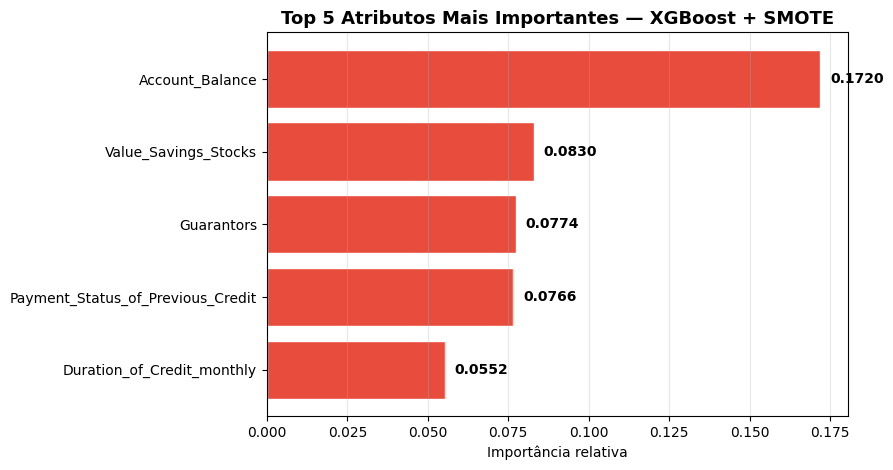

Top 5 variáveis mais importantes:
1. Account_Balance: 0.1720
2. Value_Savings_Stocks: 0.0830
3. Guarantors: 0.0774
4. Payment_Status_of_Previous_Credit: 0.0766
5. Duration_of_Credit_monthly: 0.0552


In [18]:
# Feature Importance extraída diretamente do modelo treinado neste notebook
xgb_model    = pipeline_xgb.named_steps['model']
importancias = pd.Series(
    xgb_model.feature_importances_,
    index=X_train.columns,
).sort_values(ascending=False)

importancias_top5 = importancias.head(5).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.barh(importancias_top5.index, importancias_top5.values, color=COR_RISCO, edgecolor='white')

for i, (var, val) in enumerate(importancias_top5.items()):
    ax.text(val + 0.003, i, f'{val:.4f}', va='center', fontweight='bold')

ax.set_title('Top 5 Atributos Mais Importantes — XGBoost + SMOTE', fontsize=13, fontweight='bold')
ax.set_xlabel('Importância relativa')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print('Top 5 variáveis mais importantes:')
for i, (var, imp) in enumerate(importancias_top5.sort_values(ascending=False).items(), 1):
    print(f'{i}. {var}: {imp:.4f}')

### Interpretação em linguagem de negócio

As variáveis mais importantes estão relacionadas com liquidez, poupanças, garantias, histórico de pagamentos e duração do crédito, que é exatamente o que qualquer analista de crédito analisaria manualmente.

O modelo aprende o que já é intuitivo: clientes com saldo baixo, sem poupanças, com histórico problemático ou créditos mais longos tendem a apresentar maior probabilidade de incumprimento.

# Valor para o negócio
(Ana Silva)

In [19]:
impacto = pd.DataFrame({
    'Situação': [
        'Clientes em incumprimento no teste',
        'Risco identificado pelo baseline',
        'Risco identificado pelo modelo final',
        'Risco que escapou ao modelo final',
    ],
    'Valor': [
        int((y_test == 0).sum()),
        int(cm_baseline[0, 0]),
        int(cm_final[0, 0]),
        int(cm_final[0, 1]),
    ],
    'Interpretação': [
        'Total de casos reais de risco no conjunto de teste',
        'Clientes de risco identificados pelo ponto de partida',
        'Clientes de risco sinalizados pelo modelo final',
        'Clientes de risco ainda não identificados — margem de melhoria',
    ],
})
display(impacto)

,Situação,Valor,Interpretação
0,Clientes em incumprimento no teste,60,Total de casos reais de risco no conjunto de t...
1,Risco identificado pelo baseline,31,Clientes de risco identificados pelo ponto de ...
2,Risco identificado pelo modelo final,45,Clientes de risco sinalizados pelo modelo final
3,Risco que escapou ao modelo final,15,Clientes de risco ainda não identificados — ma...


### Tradução do valor

O modelo funciona como um sistema de alerta. Não decide sozinho, mas ajuda a equipa de crédito a concentrar a análise nos clientes com maior probabilidade de incumprimento.

Na prática, isto permite:

- reduzir a aprovação indevida de crédito a clientes de maior risco;
- encaminhar casos duvidosos para análise humana;
- diferenciar processos entre clientes de baixo e alto risco;
- apoiar decisões com base em dados, sem eliminar a responsabilidade da decisão humana.

# Limitações, Ética e Trabalho Futuro
(Iara Gomes)

### Limitações dos Dados

O projeto foi desenvolvido com o German Credit Data, composto por 1000 observações. Embora útil para fins académicos, apresenta limitações relevantes:

- Os dados não representam necessariamente a realidade atual de uma instituição financeira portuguesa;
- A dimensão é relativamente reduzida para um problema de risco de crédito;
- Faltam variáveis que, num contexto real, melhorariam a análise: rendimento mensal, taxa de esforço, histórico recente de incumprimentos, taxa de juro e garantias reais;
- O desequilíbrio entre classes (70% cumprimento / 30% incumprimento) obrigou ao uso de SMOTE para compensar a sub-representação da classe de risco.

### Limitações do Modelo

- O Recall médio em validação cruzada (0,60) ficou abaixo do valor no conjunto de teste (0,75), indicando que a capacidade de deteção pode variar consoante a amostra;
- O ajuste do threshold melhora a deteção de incumprimentos, mas aumenta os falsos positivos, ou seja, existe um trade-off inevitável;
- O modelo pode ter mais dificuldade com perfis intermédios, especialmente clientes com maior esforço financeiro mensal;
- O modelo identifica padrões estatísticos, mas não prova causalidade entre as variáveis e o incumprimento.

O modelo não deve ser usado de forma automática e isolada para aprovar ou recusar crédito, uma vez que a sua utilização é mais adequada como ferramenta de triagem inicial. Pode falhar em situações como alterações económicas significativas (inflação, desemprego, subida de taxas de juro), mudanças nas políticas internas de crédito, ou clientes com perfis muito diferentes dos existentes no dataset de treino.

### Considerações Éticas

O dataset não contém identificadores pessoais diretos. Ainda assim, modelos de risco de crédito podem reproduzir desigualdades existentes nos dados históricos, variáveis como saldo bancário, poupanças ou histórico de crédito podem refletir diferenças socioeconómicas entre clientes.

Por isso, é essencial garantir que o modelo não discrimina injustamente determinados grupos, é auditado regularmente quanto a enviesamentos, e permite sempre revisão humana em casos duvidosos. A análise de importância dos atributos foi um primeiro passo neste sentido: torna o modelo mais explicável e evita que funcione como uma "caixa negra".

### Roadmap

1. Interpretabilidade com SHAP : gerar explicações individuais por previsão, permitindo ao analista perceber por que razão um cliente foi classificado como alto risco e cumprindo requisitos regulatórios de explicabilidade.
2. Enriquecimento com variáveis comportamentais e macroeconómicas : incorporar histórico de pagamentos mensais, rácio de utilização de crédito rotativo e indicadores como a Euribor para ajuste de risco sistémico.
3. Deployment com Streamlit : criar uma interface web simples onde qualquer analista possa inserir dados de um novo cliente e obter de imediato uma classificação de risco com a probabilidade associada.
4. Monitorização contínua com PSI : calcular o Population Stability Index para detetar automaticamente quando a distribuição dos dados de entrada se afasta do perfil de treino (model drift) e o modelo precisa de ser recalibrado.
5. Validação com dataset português ou europeu : testar a metodologia num contexto geograficamente mais próximo do real, dado que o German Credit Data tem limitações de representatividade temporal e geográfica.

## Conclusão
(Rita Vinagreiro)

Este projeto demonstrou que é possível construir um modelo preditivo de apoio à decisão de crédito com resultados práticos e interpretáveis.

O modelo final, **XGBoost + SMOTE**, foi escolhido porque cumpre simultaneamente as duas metas definidas no projeto:

| Meta | Resultado oficial |
|---|---:|
| F1-Score ≥ 0,80 | 0,8213 |
| Recall Incumprimento ≥ 0,70 | 0,7500 |

Em termos práticos, o modelo:

- funciona como um sistema de alerta de risco;
- identifica 45 dos 60 clientes em incumprimento no conjunto de teste;
- reduz os falsos negativos de 29 para 15 face ao baseline;
- permite segmentar clientes em diferentes níveis de risco;
- apoia a decisão humana com informação quantitativa e interpretável.

Assim, o objetivo da Milestone 4 fica cumprido: transformar o modelo técnico da Milestone 3 numa narrativa de valor, focada na utilidade real para a decisão de crédito.